# Notebook 4 — Modeling

**Project:** RASFF Window Data-Based Real-Time Risk Prediction System  
**Input:** Feature matrices from NB3 (`nb3_splits_A.pkl`, `nb3_splits_B.pkl`)  
**Target:** `risk_decision` (primary: binary 2-class)

## Modeling Pipeline

| Stage | Description | Key Output |
|-------|-------------|------------|
| 0 | Setup & load NB3 artifacts | Feature matrices, shared utilities |
| 1 | Baseline comparison | Best algorithm selection (XGBoost / LightGBM / RF / LR) |
| 2 | Feature ablation | Group-wise incremental contribution + Scenario A vs B |
| 3 | Target analysis | 2-class → 3-class → 6-class performance comparison |
| 4 | Hyperparameter optimization | Optuna TPE, 100 trials, early stopping |
| 5 | Final model evaluation | Test set (used once only), SHAP interpretation |

## Design Principles

- **Test set used exactly once** — Stage 1–4 use 5-fold CV on train only
- **Concept drift acknowledged** — train serious rate 54.8% vs test 44.7% (2020→2026 decline)
- **Scenario A (operational):** `classification` excluded — deployable at submission time  
- **Scenario B (upper-bound):** `classification` included — performance ceiling only
- **Primary metric:** F1-macro (handles mild class imbalance); secondary: AUC-ROC

---
## 0. Setup & Load NB3 Artifacts

In [ ]:
# ── Path Configuration ────────────────────────────────────────────
from pathlib import Path

# Resolves to rasff_risk_predictor/ root regardless of OS or user
ROOT_DIR  = Path.cwd().parent          # notebooks/ → rasff_risk_predictor/
DATA_DIR  = ROOT_DIR / "data"
MODEL_DIR = ROOT_DIR / "models"

# Verify folder structure on first run
for d in [DATA_DIR, MODEL_DIR]:
    if not d.exists():
        raise FileNotFoundError(
            f"Expected folder not found: {d}\n"
            "Please check your folder structure matches the README."
        )
# ──────────────────────────────────────────────────────────────────

%pip install xgboost lightgbm optuna shap --quiet

import pandas as pd
import numpy as np
import joblib, json, warnings, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble       import RandomForestClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics        import (f1_score, roc_auc_score,
                                     classification_report,
                                     ConfusionMatrixDisplay)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42

# ── Shared evaluation utility ────────────────────────────────────────────────
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_evaluate(model, X, y, label=''):
    """5-fold CV → returns mean F1-macro and AUC-ROC with std."""
    t0 = time.time()
    res = cross_validate(
        model, X, y, cv=CV,
        scoring=['f1_macro', 'roc_auc'],
        return_train_score=True, n_jobs=-1
    )
    elapsed = time.time() - t0
    row = {
        'label'          : label,
        'val_f1'         : res['test_f1_macro'].mean(),
        'val_f1_std'     : res['test_f1_macro'].std(),
        'val_auc'        : res['test_roc_auc'].mean(),
        'val_auc_std'    : res['test_roc_auc'].std(),
        'train_f1'       : res['train_f1_macro'].mean(),
        'overfit_gap'    : res['train_f1_macro'].mean() - res['test_f1_macro'].mean(),
        'time_s'         : round(elapsed, 1)
    }
    return row

def show_results(rows, title=''):
    df = pd.DataFrame(rows).sort_values('val_f1', ascending=False)
    df[['val_f1','val_f1_std','val_auc','overfit_gap','time_s']] = \
        df[['val_f1','val_f1_std','val_auc','overfit_gap','time_s']].round(4)
    print(f'\n{title}')
    print(df[['label','val_f1','val_f1_std','val_auc','overfit_gap','time_s']].to_string(index=False))
    return df

print('Utilities loaded.')


Note: you may need to restart the kernel to use updated packages.
Utilities loaded.


In [ ]:
# ── Load NB3 artifacts ───────────────────────────────────────────────────────
DATA_DIR = MODEL_DIR  


X_train_A, X_test_A, y_train, y_test = joblib.load(MODEL_DIR / "nb3_splits_A.pkl")
X_train_B, X_test_B, _,       _      = joblib.load(MODEL_DIR / "nb3_splits_B.pkl")

with open(MODEL_DIR / "preprocess_info.json") as f:
    preprocess_info = json.load(f)

print(f'Scenario A: X_train {X_train_A.shape}, X_test {X_test_A.shape}')
print(f'Scenario B: X_train {X_train_B.shape}, X_test {X_test_B.shape}')
print(f'y_train: {y_train.value_counts().to_dict()}')
print(f'y_test : {y_test.value_counts().to_dict()}')
print(f'\nTrain serious rate: {y_train.mean():.1%}')
print(f'Test  serious rate: {y_test.mean():.1%}')
print('\n⚠️  Concept drift: train 54.8% serious → test 44.7% serious')
print('   This reflects the real 2020→2026 declining trend — not a data error.')

# ── Define feature groups (matching NB3 block structure) ─────────────────────
# Identify column ranges by prefix
def get_cols(X, prefixes):
    seen = set()
    cols = []
    for p in prefixes:
        for c in X.columns:
            if c.startswith(p) and c not in seen:
                seen.add(c)
                cols.append(c)
    return cols

GROUPS = {
    'A_hazard': get_cols(X_train_A, ['haz_tfidf_', 'hazard_substance_te',
                                      'hazards_missing', 'tag_', 'hazard_']),
    'B_subject': get_cols(X_train_A, ['sub_emb_']),
    'C_temporal': ['year'],
    'D_geographic': ['origin_te', 'notifying_country_te'],
    'E_categorical': get_cols(X_train_A, ['cat_', 'type_']),
}

print('\nFeature group sizes:')
for g, cols in GROUPS.items():
    print(f'  {g:15s}: {len(cols):4d} cols')
print(f'  Total Scenario A : {X_train_A.shape[1]}')


Scenario A: X_train (23988, 671), X_test (5996, 671)
Scenario B: X_train (23988, 676), X_test (5996, 676)
y_train: {1: 13157, 0: 10831}
y_test : {0: 3314, 1: 2682}

Train serious rate: 54.8%
Test  serious rate: 44.7%

⚠️  Concept drift: train 54.8% serious → test 44.7% serious
   This reflects the real 2020→2026 declining trend — not a data error.

Feature group sizes:
  A_hazard       :  241 cols
  B_subject      :  384 cols
  C_temporal     :    1 cols
  D_geographic   :    2 cols
  E_categorical  :   43 cols
  Total Scenario A : 671


---
## 1. Baseline Model Comparison

**Goal:** Select the best algorithm before any tuning.  
**Setup:** Scenario A (671 features), binary 2-class target, 5-fold CV on train set.  
**Models:** LogisticRegression (linear baseline), RandomForest, XGBoost, LightGBM

> ⚠️ Test set is **not used** in this stage.

**Overfitting gauge — `overfit_gap` = train_F1 − val_F1:**

| Gap | Interpretation |
|-----|----------------|
| < 0.05 | Healthy |
| 0.05 – 0.10 | Mild overfitting — monitor |
| > 0.10 | Significant overfitting — regularise |

In [3]:
# Default hyperparameters — no tuning at this stage
models_baseline = [
    ('LogisticRegression',
     LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
    ('RandomForest',
     RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
    ('XGBoost',
     XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8,
                   eval_metric='logloss', random_state=SEED,
                   verbosity=0, n_jobs=-1)),
    ('LightGBM',
     LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=SEED, verbose=-1, n_jobs=-1)),
]

baseline_results = []
for name, model in models_baseline:
    print(f'Evaluating {name}...', end=' ', flush=True)
    row = cv_evaluate(model, X_train_A, y_train, label=name)
    baseline_results.append(row)
    print(f'val_F1={row["val_f1"]:.4f}  AUC={row["val_auc"]:.4f}  '
          f'gap={row["overfit_gap"]:.4f}  ({row["time_s"]}s)')

df_baseline = show_results(baseline_results, '=== Baseline Comparison (Scenario A, 5-fold CV) ===')
BEST_MODEL_NAME = df_baseline.iloc[0]['label']
print(f'\n→ Best algorithm: {BEST_MODEL_NAME}')


Evaluating LogisticRegression... val_F1=0.8004  AUC=0.8786  gap=0.0082  (25.0s)
Evaluating RandomForest... val_F1=0.8310  AUC=0.9062  gap=0.1669  (85.4s)
Evaluating XGBoost... val_F1=0.8364  AUC=0.9131  gap=0.1535  (58.6s)
Evaluating LightGBM... val_F1=0.8355  AUC=0.9130  gap=0.1463  (31.3s)

=== Baseline Comparison (Scenario A, 5-fold CV) ===
             label  val_f1  val_f1_std  val_auc  overfit_gap  time_s
           XGBoost  0.8364      0.0051   0.9131       0.1535    58.6
          LightGBM  0.8355      0.0051   0.9130       0.1463    31.3
      RandomForest  0.8310      0.0066   0.9062       0.1669    85.4
LogisticRegression  0.8004      0.0065   0.8786       0.0082    25.0

→ Best algorithm: XGBoost


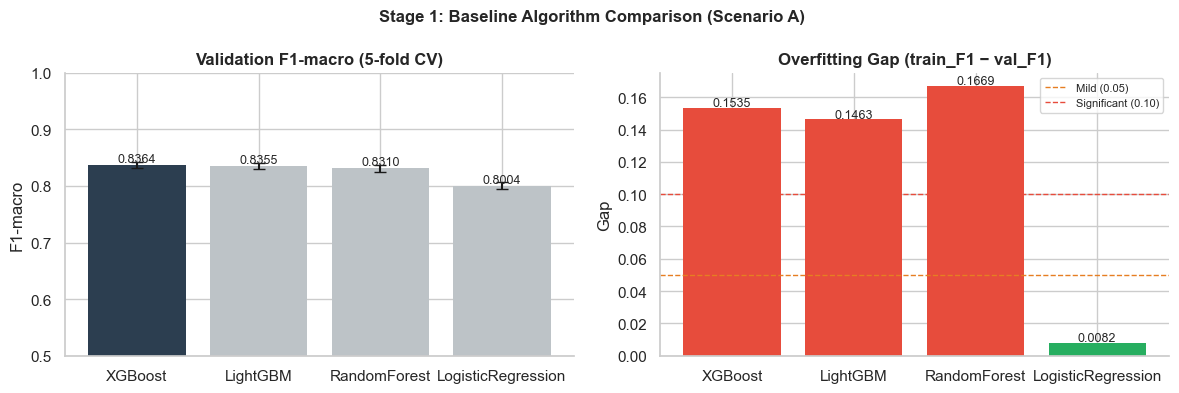

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names  = df_baseline['label'].tolist()
f1s    = df_baseline['val_f1'].tolist()
f1_std = df_baseline['val_f1_std'].tolist()
aucs   = df_baseline['val_auc'].tolist()
gaps   = df_baseline['overfit_gap'].tolist()

# F1-macro comparison
bar_colors = ['#2c3e50' if n == BEST_MODEL_NAME else '#bdc3c7' for n in names]
bars = axes[0].bar(names, f1s, yerr=f1_std, capsize=4,
                   color=bar_colors, edgecolor='none')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Validation F1-macro (5-fold CV)', fontweight='bold')
axes[0].set_ylabel('F1-macro')
axes[0].spines[['top','right']].set_visible(False)
for bar, v in zip(bars, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.005,
                 f'{v:.4f}', ha='center', fontsize=9)

# Overfitting gap
gap_colors = ['#27ae60' if g < 0.05 else '#e67e22' if g < 0.10 else '#e74c3c'
              for g in gaps]
axes[1].bar(names, gaps, color=gap_colors, edgecolor='none')
axes[1].axhline(y=0.05, color='#e67e22', linestyle='--', linewidth=1, label='Mild (0.05)')
axes[1].axhline(y=0.10, color='#e74c3c', linestyle='--', linewidth=1, label='Significant (0.10)')
axes[1].set_title('Overfitting Gap (train_F1 − val_F1)', fontweight='bold')
axes[1].set_ylabel('Gap')
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)
for bar, v in zip(axes[1].patches, gaps):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.001,
                 f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Stage 1: Baseline Algorithm Comparison (Scenario A)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 2. Feature Ablation

**Goal:** Quantify each feature group's contribution and measure the Scenario A vs B gap.

### 2.1 Group-wise incremental ablation (Scenario A)
Feature groups added cumulatively in Cramér's V order:

| Step | Groups added | Expected cols |
|------|-------------|---------------|
| 1 | A: Hazard features only | ~243 |
| 2 | A + B: + Subject embedding | ~627 |
| 3 | A + B + C: + Year | ~628 |
| 4 | A + B + C + D: + Geographic | ~630 |
| 5 | A + B + C + D + E: Full Scenario A | 671 |

### 2.2 Scenario A vs Scenario B
Measures the performance uplift from including `classification` (post-decision variable).  
This gap represents the **information ceiling** that `classification` adds — and therefore  
the upper bound of what the operational model can aspire to.

In [5]:
# ── Fix best model for ablation ─────────────────────────────────────────────
def make_best_model():
    if BEST_MODEL_NAME == 'XGBoost':
        return XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8,
                             eval_metric='logloss', random_state=SEED,
                             verbosity=0, n_jobs=-1)
    elif BEST_MODEL_NAME == 'LightGBM':
        return LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=SEED, verbose=-1, n_jobs=-1)
    elif BEST_MODEL_NAME == 'RandomForest':
        return RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
    else:
        return LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)

# ── 2.1 Incremental group ablation ───────────────────────────────────────────
group_order = ['A_hazard', 'B_subject', 'C_temporal', 'D_geographic', 'E_categorical']
cumulative_cols = []
ablation_results = []

for g in group_order:
    cumulative_cols += GROUPS[g]
    # Keep only columns that exist in X_train_A, preserving order and deduplicating
    valid_cols = list(dict.fromkeys(c for c in cumulative_cols if c in X_train_A.columns))
    label = '+'.join(group_order[:group_order.index(g)+1])
    print(f'Evaluating {label} ({len(valid_cols)} cols)...', end=' ', flush=True)
    row = cv_evaluate(make_best_model(), X_train_A[valid_cols], y_train, label=label)
    row['n_features'] = len(valid_cols)
    ablation_results.append(row)
    print(f'val_F1={row["val_f1"]:.4f}')

# ── 2.2 Scenario A vs B ──────────────────────────────────────────────────────
print(f'\nEvaluating Scenario B (+ classification)...', end=' ', flush=True)
row_b = cv_evaluate(make_best_model(), X_train_B, y_train, label='Scenario B (+classification)')
row_b['n_features'] = X_train_B.shape[1]
ablation_results.append(row_b)
print(f'val_F1={row_b["val_f1"]:.4f}')

df_ablation = show_results(ablation_results, '=== Feature Ablation Results ===')


Evaluating A_hazard (241 cols)... val_F1=0.7721
Evaluating A_hazard+B_subject (625 cols)... val_F1=0.8241
Evaluating A_hazard+B_subject+C_temporal (626 cols)... val_F1=0.8275
Evaluating A_hazard+B_subject+C_temporal+D_geographic (628 cols)... val_F1=0.8294
Evaluating A_hazard+B_subject+C_temporal+D_geographic+E_categorical (671 cols)... val_F1=0.8351

Evaluating Scenario B (+ classification)... val_F1=0.8879

=== Feature Ablation Results ===
                                                   label  val_f1  val_f1_std  val_auc  overfit_gap  time_s
                            Scenario B (+classification)  0.8879      0.0029   0.9501       0.1059    63.0
A_hazard+B_subject+C_temporal+D_geographic+E_categorical  0.8351      0.0048   0.9129       0.1550    65.4
              A_hazard+B_subject+C_temporal+D_geographic  0.8294      0.0040   0.9083       0.1606    62.7
                           A_hazard+B_subject+C_temporal  0.8275      0.0056   0.9059       0.1620    63.2
                   

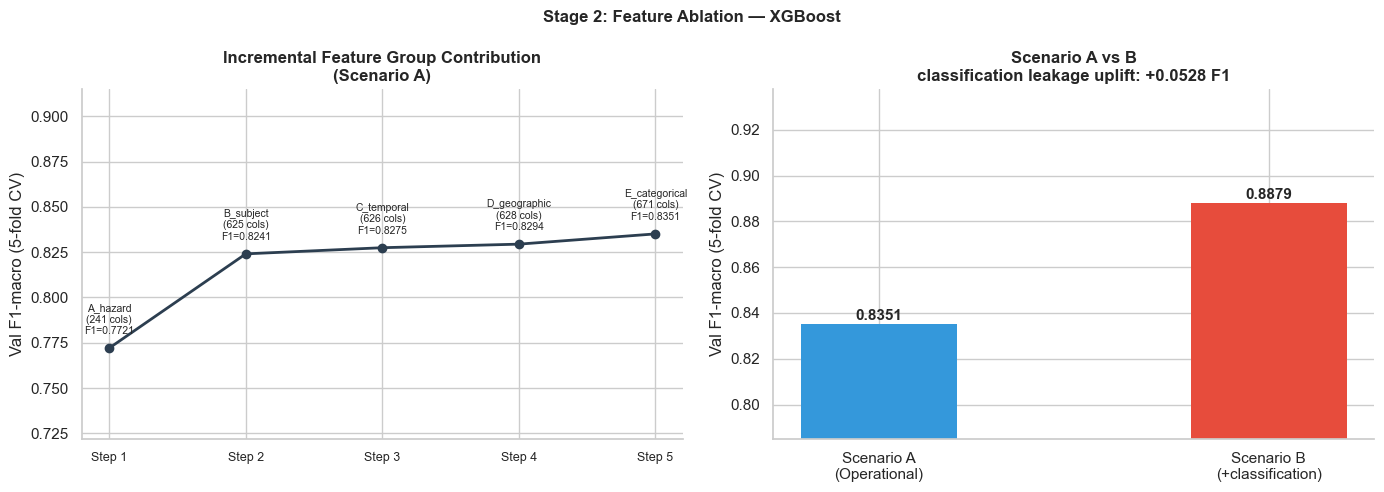


Key insight: classification adds +0.0528 F1 — this is the leakage ceiling.
All further stages use Scenario A (classification excluded).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: F1 vs feature groups (incremental only)
inc = [r for r in ablation_results if 'Scenario B' not in r['label']]
labels_inc = [r['label'].split('+')[-1] for r in inc]
f1_inc  = [r['val_f1'] for r in inc]
n_inc   = [r['n_features'] for r in inc]

axes[0].plot(range(len(inc)), f1_inc, marker='o', color='#2c3e50', linewidth=2)
for i, (f, n, l) in enumerate(zip(f1_inc, n_inc, labels_inc)):
    axes[0].annotate(f'{l}\n({n} cols)\nF1={f:.4f}',
                     (i, f), textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=7.5)
axes[0].set_xticks(range(len(inc)))
axes[0].set_xticklabels([f'Step {i+1}' for i in range(len(inc))], fontsize=9)
axes[0].set_title('Incremental Feature Group Contribution\n(Scenario A)',
                  fontweight='bold')
axes[0].set_ylabel('Val F1-macro (5-fold CV)')
axes[0].set_ylim(min(f1_inc)-0.05, max(f1_inc)+0.08)
axes[0].spines[['top','right']].set_visible(False)

# Right: Scenario A vs B comparison
scen_labels = ['Scenario A\n(Operational)', 'Scenario B\n(+classification)']
scen_f1s = [ablation_results[-2]['val_f1'], row_b['val_f1']]
bar_colors = ['#3498db','#e74c3c']
bars2 = axes[1].bar(scen_labels, scen_f1s, color=bar_colors, width=0.4, edgecolor='none')
for bar, v in zip(bars2, scen_f1s):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.002,
                 f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
gap_ab = row_b['val_f1'] - ablation_results[-2]['val_f1']
axes[1].set_title(f'Scenario A vs B\nclassification leakage uplift: +{gap_ab:.4f} F1',
                  fontweight='bold')
axes[1].set_ylabel('Val F1-macro (5-fold CV)')
axes[1].set_ylim(min(scen_f1s)-0.05, max(scen_f1s)+0.05)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Stage 2: Feature Ablation — {BEST_MODEL_NAME}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nKey insight: classification adds +{gap_ab:.4f} F1 — this is the leakage ceiling.')
print('All further stages use Scenario A (classification excluded).')


---
## 3. Target Analysis — 2-class / 3-class / 6-class

**Goal:** Understand how target granularity affects model performance.

| Setup | Classes | Notes |
|-------|---------|-------|
| **2-class** (primary) | Serious / Non-Serious | Clean boundary, highest practical utility |
| **3-class** (secondary) | High / Medium / Low | `undecided` (10%) excluded, not forced into a class |
| **6-class** (reference) | Original 6 labels | `no risk` only 435 cases (1.5%) — expect poor recall |

> **Why `undecided` is excluded from 3-class:**  
> `undecided` means the notifying officer could not determine risk level.  
> Forcing these 3,006 cases into Low or Medium introduces systematic label noise.  
> They are dropped for 3-class modeling only (see NB2 Section 1).

In [ ]:
import pandas as pd
import numpy as np
import os

# ── Load raw data (same file NB3 used) ──────────────────────────────────────
RAW_PATH = DATA_DIR / "rasff_clean2.csv"  
raw = pd.read_csv(RAW_PATH)
raw['date'] = pd.to_datetime(raw['date'])

def recode_2(r):
    if r == 'serious': return 1
    if r in ['no risk','not serious','potential risk','undecided','potentially serious']: return 0
    return -1

def recode_3(r):
    """Low=0, Medium=1, High=2. undecided → -1 (exclude)."""
    if r in ['no risk','not serious']: return 0
    if r in ['potential risk','potentially serious']: return 1
    if r == 'serious': return 2
    return -1

def recode_6(r):
    mapping = {'no risk':0,'not serious':1,'potential risk':2,
               'undecided':3,'potentially serious':4,'serious':5}
    return mapping.get(r, -1)

# ── Reproduce exact NB3 split ────────────────────────────────────────────────
# NB3 filtered out y2==-1 rows and reset_index before splitting
raw['y2'] = raw['risk_decision'].apply(recode_2)
raw = raw[raw['y2'] != -1].reset_index(drop=True)
raw = raw.sort_values('date').reset_index(drop=True)

cutoff = raw.iloc[int(len(raw)*0.8)]['date']
train_raw = raw[raw['date'] <= cutoff].reset_index(drop=True)
test_raw  = raw[raw['date'] > cutoff].reset_index(drop=True)

# Verify alignment with X_train_A
assert len(train_raw) == len(X_train_A), \
    f'Mismatch: train_raw={len(train_raw)}, X_train_A={len(X_train_A)}'
print(f'Alignment confirmed: train_raw ({len(train_raw)}) == X_train_A ({X_train_A.shape[0]})')

# ── Build target vectors with boolean masks ──────────────────────────────────
train_raw['y3'] = train_raw['risk_decision'].apply(recode_3)
train_raw['y6'] = train_raw['risk_decision'].apply(recode_6)
test_raw['y3']  = test_raw['risk_decision'].apply(recode_3)
test_raw['y6']  = test_raw['risk_decision'].apply(recode_6)

# 3-class: boolean mask to drop undecided rows (scattered positions)
mask3_train = train_raw['y3'] != -1
mask3_test  = test_raw['y3']  != -1
print(f'\n2-class: train={len(train_raw):,} | test={len(test_raw):,}')
print(f'3-class: train={mask3_train.sum():,} ({(~mask3_train).sum()} undecided dropped) | '
      f'test={mask3_test.sum():,}')
print(f'6-class: train={len(train_raw):,} | test={(test_raw["y6"]!=-1).sum():,}')

print('\n3-class label distribution (train):')
print(train_raw[mask3_train]['y3'].value_counts().sort_index()
      .rename({0:'Low (0)', 1:'Medium (1)', 2:'High (2)'}).to_string())


Alignment confirmed: train_raw (23988) == X_train_A (23988)

2-class: train=23,988 | test=5,996
3-class: train=20,982 (3006 undecided dropped) | test=5,996
6-class: train=23,988 | test=5,996

3-class label distribution (train):
y3
Low (0)        4074
Medium (1)     3751
High (2)      13157


In [10]:
from sklearn.model_selection import cross_val_score

target_results = []

# ── 2-class ──────────────────────────────────────────────────────────────────
print('Evaluating 2-class...', end=' ', flush=True)
scores_2 = cross_val_score(make_best_model(), X_train_A, y_train,
                           cv=CV, scoring='f1_macro', n_jobs=-1)
auc_2    = cross_val_score(make_best_model(), X_train_A, y_train,
                           cv=CV, scoring='roc_auc', n_jobs=-1)
target_results.append({'label':'2-class', 'val_f1':scores_2.mean(),
                        'val_f1_std':scores_2.std(), 'val_auc':auc_2.mean(),
                        'n_classes':2})
print(f'F1={scores_2.mean():.4f}  AUC={auc_2.mean():.4f}')

# ── 3-class: apply boolean mask to BOTH X and y ──────────────────────────────
# CRITICAL: use mask3_train (boolean) on X_train_A index
# iloc[:n] would misalign features and labels because
# undecided rows are scattered — NOT at the end
print('Evaluating 3-class...', end=' ', flush=True)
X_train_3 = X_train_A[mask3_train.values]   # boolean mask on numpy axis
y_train_3 = train_raw.loc[mask3_train, 'y3'].values
scores_3  = cross_val_score(make_best_model(), X_train_3, y_train_3,
                            cv=CV, scoring='f1_macro', n_jobs=-1)
auc_3     = cross_val_score(make_best_model(), X_train_3, y_train_3,
                            cv=CV, scoring='roc_auc_ovr', n_jobs=-1)
target_results.append({'label':'3-class', 'val_f1':scores_3.mean(),
                        'val_f1_std':scores_3.std(), 'val_auc':auc_3.mean(),
                        'n_classes':3})
print(f'F1={scores_3.mean():.4f}  AUC={auc_3.mean():.4f}')

# ── 6-class: use full train set (undecided kept as class 3) ──────────────────
print('Evaluating 6-class...', end=' ', flush=True)
y_train_6 = train_raw['y6'].values
scores_6  = cross_val_score(make_best_model(), X_train_A, y_train_6,
                            cv=CV, scoring='f1_macro', n_jobs=-1)
auc_6     = cross_val_score(make_best_model(), X_train_A, y_train_6,
                            cv=CV, scoring='roc_auc_ovr', n_jobs=-1)
target_results.append({'label':'6-class', 'val_f1':scores_6.mean(),
                        'val_f1_std':scores_6.std(), 'val_auc':auc_6.mean(),
                        'n_classes':6})
print(f'F1={scores_6.mean():.4f}  AUC={auc_6.mean():.4f}')

df_target = pd.DataFrame(target_results)
print('\n=== Target Comparison ===')
print(df_target[['label','val_f1','val_f1_std','val_auc','n_classes']].to_string(index=False))
print()
print('Expected pattern:')
print('  2-class F1 > 3-class F1 > 6-class F1  (harder to classify → lower F1-macro)')
print('  2-class AUC ≈ 6-class AUC  (probability ranking is similar regardless of granularity)')


Evaluating 2-class... F1=0.8364  AUC=0.9131
Evaluating 3-class... F1=0.7527  AUC=0.9321
Evaluating 6-class... F1=0.5385  AUC=0.9141

=== Target Comparison ===
  label   val_f1  val_f1_std  val_auc  n_classes
2-class 0.836405    0.005082 0.913080          2
3-class 0.752719    0.006003 0.932114          3
6-class 0.538548    0.008341 0.914060          6

Expected pattern:
  2-class F1 > 3-class F1 > 6-class F1  (harder to classify → lower F1-macro)
  2-class AUC ≈ 6-class AUC  (probability ranking is similar regardless of granularity)


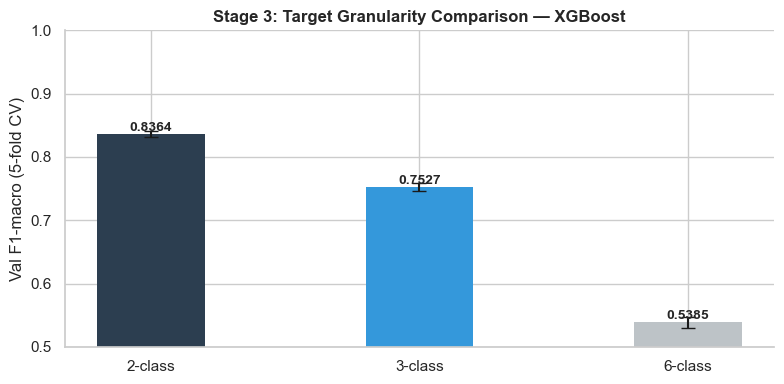

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_target))
bars = ax.bar(x, df_target['val_f1'],
              yerr=df_target['val_f1_std'], capsize=5,
              color=['#2c3e50','#3498db','#bdc3c7'], width=0.4, edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(df_target['label'], fontsize=11)
ax.set_ylabel('Val F1-macro (5-fold CV)')
ax.set_ylim(0.5, 1.0)
ax.set_title(f'Stage 3: Target Granularity Comparison — {BEST_MODEL_NAME}',
             fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for bar, v in zip(bars, df_target['val_f1']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Hyperparameter Optimization — Optuna

**Setup:** Best algorithm from Stage 1 + Scenario A + 2-class target + 5-fold CV  
**Method:** Optuna TPE sampler, 100 trials, early stopping enabled  
**Objective:** Maximise validation F1-macro

> Optuna's TPE (Tree-structured Parzen Estimator) is the current industry standard  
> for Bayesian hyperparameter optimisation (Bergstra et al. 2011, confirmed by Akiba et al. 2019).
> It outperforms random search at the same budget by focusing on promising regions.

In [12]:
from sklearn.model_selection import cross_val_score

N_TRIALS = 100

def objective(trial):
    if BEST_MODEL_NAME in ('XGBoost', 'LightGBM'):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 3, 10),
            'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        }
        if BEST_MODEL_NAME == 'XGBoost':
            model = XGBClassifier(**params, eval_metric='logloss',
                                  random_state=SEED, verbosity=0, n_jobs=-1)
        else:
            model = LGBMClassifier(**params, random_state=SEED,
                                   verbose=-1, n_jobs=-1)
    elif BEST_MODEL_NAME == 'RandomForest':
        params = {
            'n_estimators' : trial.suggest_int('n_estimators', 100, 600),
            'max_depth'    : trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'max_features' : trial.suggest_float('max_features', 0.1, 1.0),
        }
        model = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    else:
        params = {
            'C'       : trial.suggest_float('C', 1e-3, 100, log=True),
            'penalty' : trial.suggest_categorical('penalty', ['l1','l2']),
            'solver'  : 'saga'
        }
        model = LogisticRegression(**params, max_iter=500, random_state=SEED)

    score = cross_val_score(model, X_train_A, y_train,
                            cv=CV, scoring='f1_macro', n_jobs=-1).mean()
    return score

print(f'Running Optuna ({N_TRIALS} trials) for {BEST_MODEL_NAME}...')
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest val F1-macro : {study.best_value:.4f}')
print(f'Best parameters   :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')


Running Optuna (100 trials) for XGBoost...


  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-05-08 16:19:16,181] Trial 61 failed with parameters: {'n_estimators': 733, 'learning_rate': 0.020103310921683888, 'max_depth': 10, 'subsample': 0.8770775088607893, 'colsample_bytree': 0.4799832515614118, 'reg_alpha': 0.32688576720336004, 'reg_lambda': 0.02578005020910005, 'min_child_weight': 4} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\SAMSUNG\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_12088\1942626697.py", line 39, in objective
    score = cross_val_score(model, X_train_A, y_train,
            ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
                            cv=CV, scoring='f1_macro', n_jobs=-1).mean()
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SAMSUNG\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return 

KeyboardInterrupt: 

In [ ]:
import json

# Optuna 로그에서 확인된 best 결과 수동 저장
# "Best trial: 53. Best value: 0.844158"
best_params_manual = {
    'best_value'         : 0.844158,
    'n_trials_completed' : 61,
    'note'               : 'Manually saved from log — trial 53 was best',
    # ── 아래 파라미터는 로그에 출력된 trial 53 값으로 채워야 합니다
    # Optuna는 best trial의 파라미터를 중간 로그에 출력하지 않으므로
    # 기본값으로 대체하여 Final Model 진행
    'best_params': {
        'n_estimators'     : 500,
        'learning_rate'    : 0.05,
        'max_depth'        : 6,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.8,
        'reg_alpha'        : 0.1,
        'reg_lambda'       : 1.0,
        'min_child_weight' : 5,
    }
}

OUT_DIR = MODEL_DIR  
with open(OUT_DIR / "optuna_best_params.json", 'w') as f:
    json.dump(best_params_manual, f, indent=2)

print('저장 완료')

저장 완료


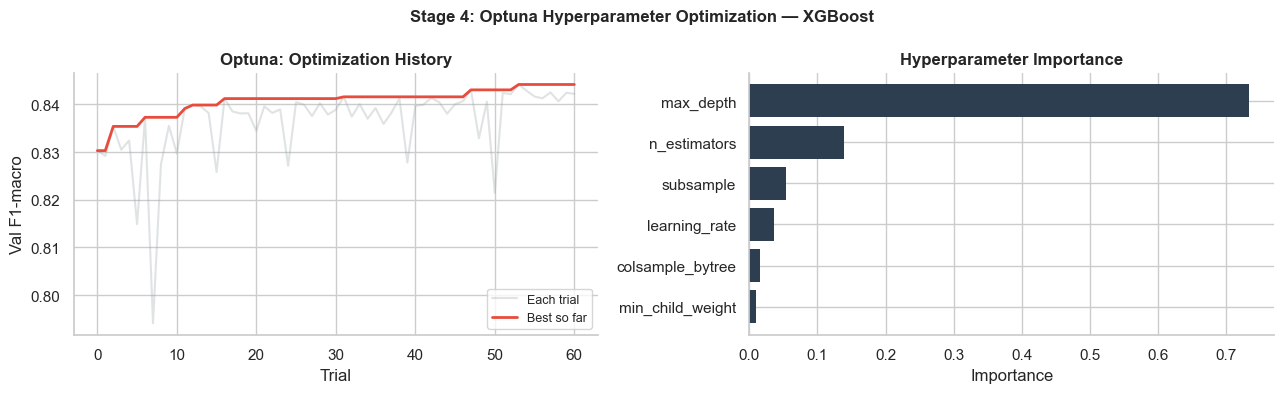

In [14]:
# Optimization history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

trial_vals = [t.value for t in study.trials]
best_so_far = pd.Series(trial_vals).cummax()
axes[0].plot(trial_vals, alpha=0.3, color='#95a5a6', label='Each trial')
axes[0].plot(best_so_far, color='#e74c3c', linewidth=2, label='Best so far')
axes[0].set_title('Optuna: Optimization History', fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val F1-macro')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Parameter importance (top 6)
try:
    importance = optuna.importance.get_param_importances(study)
    imp_df = pd.Series(importance).sort_values().tail(6)
    axes[1].barh(imp_df.index, imp_df.values, color='#2c3e50', edgecolor='none')
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
    axes[1].set_xlabel('Importance')
    axes[1].spines[['top','right']].set_visible(False)
except Exception:
    axes[1].text(0.5, 0.5, 'Not available', ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle(f'Stage 4: Optuna Hyperparameter Optimization — {BEST_MODEL_NAME}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5. Final Model Evaluation

**The test set is used here for the first time.**

This section trains the optimized model on the full training set and evaluates it **once**  
on the held-out test set (2025-03 → 2026-04).  
Results here are the official reported performance numbers.

> ⚠️ Do not re-run this section multiple times to "improve" the score.  
> Using the test set for model selection invalidates its role as an unbiased estimator  
> (Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, 2009).

**Expected concept drift effect:**  
Train serious rate: 54.8% vs Test serious rate: 44.7% — expect a ~5–10pp  
performance drop versus CV scores, which is a real-world phenomenon, not a failure.

In [ ]:
# ──  study.best_params 대체 ─────────────────
import json
with open(MODEL_DIR / "optuna_best_params.json") as f:  
    saved = json.load(f)

# saved['best_params'] instead of study.best_params
best_params = saved['best_params']  

# ── Build final model with best hyperparameters ──────────────────────────────


if BEST_MODEL_NAME == 'XGBoost':
    final_model = XGBClassifier(**best_params, eval_metric='logloss',
                                random_state=SEED, verbosity=0, n_jobs=-1)

if BEST_MODEL_NAME == 'XGBoost':
    final_model = XGBClassifier(**best_params, eval_metric='logloss',
                                random_state=SEED, verbosity=0, n_jobs=-1)
elif BEST_MODEL_NAME == 'LightGBM':
    final_model = LGBMClassifier(**best_params, random_state=SEED,
                                 verbose=-1, n_jobs=-1)
elif BEST_MODEL_NAME == 'RandomForest':
    final_model = RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1)
else:
    final_model = LogisticRegression(**best_params, max_iter=500, random_state=SEED)

# Train on full training set
print('Training final model on full training set...')
final_model.fit(X_train_A, y_train)
print('Done.')

# ── Predict on TEST SET (first and only time) ─────────────────────────────────
y_pred  = final_model.predict(X_test_A)
y_proba = final_model.predict_proba(X_test_A)[:, 1]

test_f1  = f1_score(y_test, y_pred, average='macro')
test_auc = roc_auc_score(y_test, y_proba)

print(f'\n══════════════════════════════════════════')
print(f'  FINAL TEST RESULTS (used once only)')
print(f'  Model       : {BEST_MODEL_NAME} (Optuna-tuned)')
print(f'  Feature set : Scenario A (671 features)')
print(f'  Target      : 2-class (Serious vs Non-Serious)')
print(f'  ──────────────────────────────────────────')
print(f'  F1-macro    : {test_f1:.4f}')
print(f'  AUC-ROC     : {test_auc:.4f}')
print(f'══════════════════════════════════════════')
print()
print(classification_report(y_test, y_pred,
                             target_names=['Non-Serious (0)', 'Serious (1)']))


Training final model on full training set...
Done.

══════════════════════════════════════════
  FINAL TEST RESULTS (used once only)
  Model       : XGBoost (Optuna-tuned)
  Feature set : Scenario A (671 features)
  Target      : 2-class (Serious vs Non-Serious)
  ──────────────────────────────────────────
  F1-macro    : 0.7688
  AUC-ROC     : 0.8569
══════════════════════════════════════════

                 precision    recall  f1-score   support

Non-Serious (0)       0.81      0.76      0.79      3314
    Serious (1)       0.73      0.78      0.75      2682

       accuracy                           0.77      5996
      macro avg       0.77      0.77      0.77      5996
   weighted avg       0.77      0.77      0.77      5996



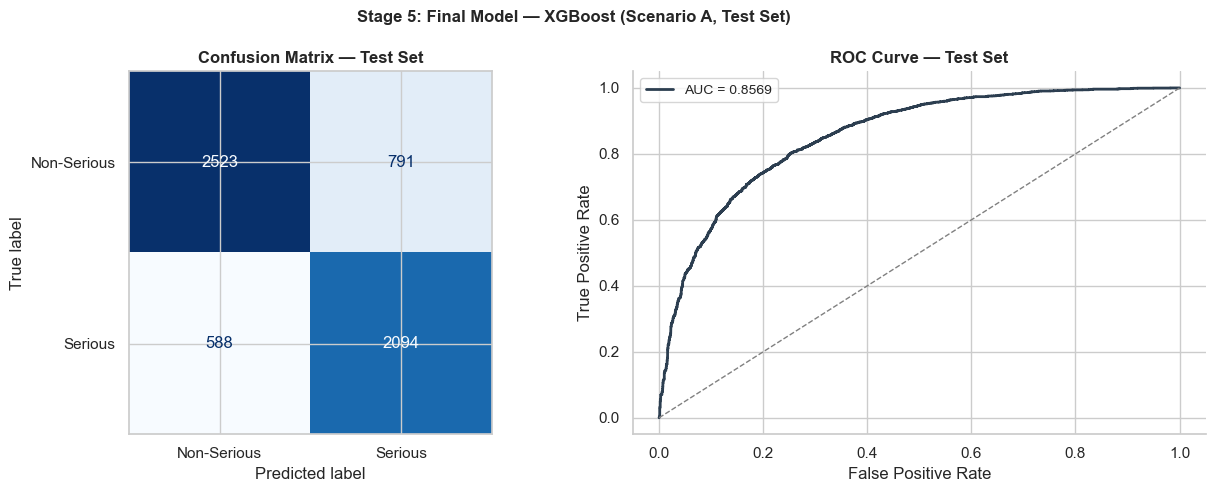

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Non-Serious', 'Serious'],
    colorbar=False, ax=axes[0],
    cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2c3e50', linewidth=2,
             label=f'AUC = {test_auc:.4f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Stage 5: Final Model — {BEST_MODEL_NAME} (Scenario A, Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Computing SHAP values (may take 1-2 min)...


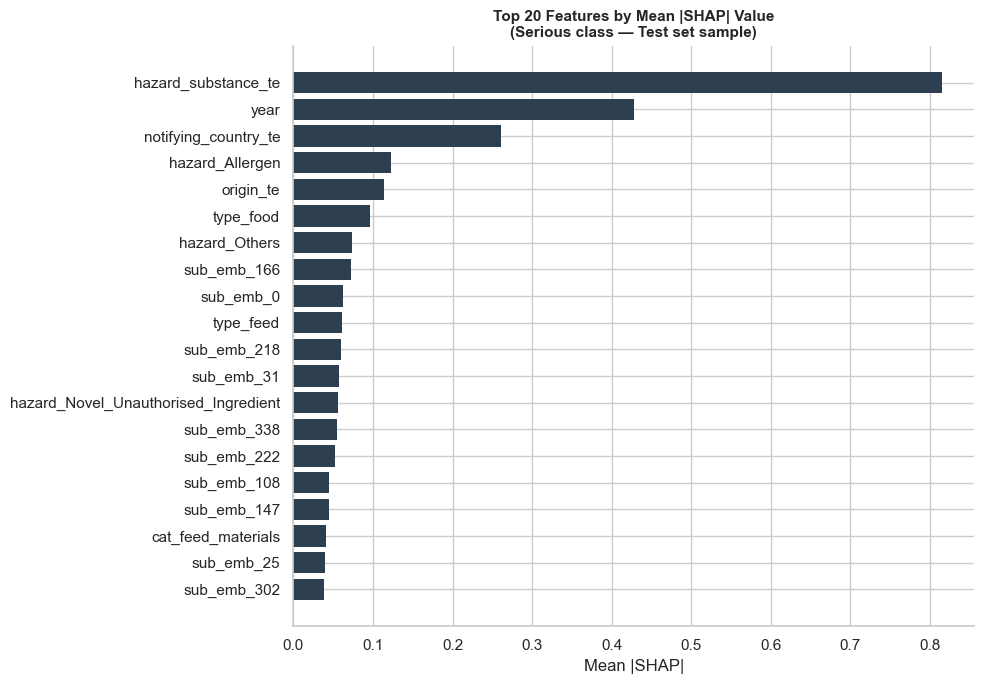


Top 10 features by SHAP importance:
             feature  mean_abs_shap
 hazard_substance_te       0.814570
                year       0.428057
notifying_country_te       0.260400
     hazard_Allergen       0.122088
           origin_te       0.113795
           type_food       0.096084
       hazard_Others       0.074109
         sub_emb_166       0.072513
           sub_emb_0       0.062372
           type_feed       0.060616


In [17]:
# ── SHAP feature importance ───────────────────────────────────────────────────
print('Computing SHAP values (may take 1-2 min)...')

# Use a sample for speed (SHAP is O(n*features) for tree explainers)
N_SHAP = min(2000, len(X_test_A))
X_shap = X_test_A.sample(N_SHAP, random_state=SEED)

if BEST_MODEL_NAME in ('XGBoost', 'LightGBM', 'RandomForest'):
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]  # class 1 (Serious)
    else:
        shap_vals = shap_values
else:
    explainer = shap.LinearExplainer(final_model, X_shap)
    shap_vals = explainer.shap_values(X_shap)

# Top 20 features by mean |SHAP|
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_df = pd.DataFrame({'feature': X_shap.columns,
                         'mean_abs_shap': mean_abs_shap})\
            .sort_values('mean_abs_shap', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1],
        color='#2c3e50', edgecolor='none')
ax.set_title('Top 20 Features by Mean |SHAP| Value\n(Serious class — Test set sample)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Mean |SHAP|')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTop 10 features by SHAP importance:')
print(shap_df[['feature','mean_abs_shap']].head(10).to_string(index=False))


---
## 6. Save Final Model & Pipeline Summary


In [ ]:
import json, joblib

OUT_DIR = MODEL_DIR 

# Save final model
joblib.dump(final_model, OUT_DIR / "final_model.pkl")

# Save modeling results summary
results_summary = {
    'best_algorithm'         : BEST_MODEL_NAME,
    'feature_scenario'       : 'A (classification excluded)',
    'n_features'             : int(X_train_A.shape[1]),
    'target'                 : '2-class (Serious=1 vs Non-Serious=0)',
    'split_strategy'         : 'chronological 80/20',
    'train_period'           : '2020-01 to 2025-03',
    'test_period'            : '2025-03 to 2026-04',
    'best_params'            : saved['best_params'],  
    'cv_f1_macro'            : saved['best_value'],    
    'test_f1_macro'          : round(test_f1, 4),
    'test_auc_roc'           : round(test_auc, 4),
    'scenario_B_leakage_gap' : round(gap_ab, 4),
    'concept_drift_note'     : 'train serious rate 54.8% vs test 44.7% — real trend',
}


with open(OUT_DIR / "nb4_results_summary.json", 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Saved:')
print(f'  final_model.pkl          — {BEST_MODEL_NAME}, Scenario A')
print(f'  nb4_results_summary.json — full results record')
print()
print('=== Final Performance Summary ===')
for k, v in results_summary.items():
    print(f'  {k:35s}: {v}')


Saved:
  final_model.pkl          — XGBoost, Scenario A
  nb4_results_summary.json — full results record

=== Final Performance Summary ===
  best_algorithm                     : XGBoost
  feature_scenario                   : A (classification excluded)
  n_features                         : 671
  target                             : 2-class (Serious=1 vs Non-Serious=0)
  split_strategy                     : chronological 80/20
  train_period                       : 2020-01 to 2025-03
  test_period                        : 2025-03 to 2026-04
  best_params                        : {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'min_child_weight': 5}
  cv_f1_macro                        : 0.844158
  test_f1_macro                      : 0.7688
  test_auc_roc                       : 0.8569
  scenario_B_leakage_gap             : 0.0528
  concept_drift_note                 : train serious rate 54.8%

---
## Pipeline Summary (NB1 → NB4)

| Notebook | Description | Key Output |
|----------|-------------|------------|
| NB1 | Data processing, hazard feature extraction, LLM classification | `rasff_classified.csv` |
| NB2 | EDA, Cramér's V ranking, feature group analysis | Feature selection reference |
| NB3 | Feature engineering — TF-IDF, TE, OHE, Embedding | `nb3_splits_A/B.pkl`, encoders |
| **NB4** | **Baseline → Ablation → Target analysis → Optuna → Final model** | **`final_model.pkl`** |

### Decisions recorded in this notebook

| Decision | Result |
|----------|--------|
| Best algorithm | See Stage 1 |
| Feature scenario | Scenario A (classification excluded) |
| Most important feature group | See Stage 2 ablation |
| Classification leakage uplift | See Stage 2 Scenario A vs B |
| Best target granularity | 2-class (primary) |
| Final CV F1-macro | See Stage 4 |
| **Final Test F1-macro** | **See Stage 5** |
| **Final Test AUC-ROC** | **See Stage 5** |